### Step 1: Install necesscary packages

In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


### Step 2: Package imports and configuration

In [2]:
import sys
import os
sys.path.append(os.path.abspath("..")) 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import pickle
from model import GPT, GPTConfig
import random
from tqdm import tqdm
import time
import json
import math
import matplotlib.pyplot as plt
# Configuration
beta = 0.5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
base_lr = 1e-4
epochs = 5
batch_size = 64
max_length =64
num_samples = 1
max_new_tokens = 200
temperature = 0.8
top_k = 200
# tokenizer
with open("../sft/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi, itos = meta["stoi"], meta["itos"]
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

### Step 3: Define helper functions

In [3]:
def compute_logprob(input_ids):
    inputs = input_ids[:, :-1]
    targets = input_ids[:, 1:]
    logits, _ = gpt(inputs, full_seq=True)
    B, T, V = logits.size()
    logits_flat = logits.reshape(-1, V)
    targets_flat = targets.reshape(-1)
    loss = F.cross_entropy(logits_flat, targets_flat, ignore_index=0, reduction='none')
    loss = loss.reshape(B, T)
    attention_mask = (targets != 0).float()
    loss = (loss * attention_mask).sum(dim=1) / attention_mask.sum(dim=1)
    return -loss 

def pad_or_truncate(seq, max_length):
    return seq[-max_length:] if len(seq) > max_length else seq + [0] * (max_length - len(seq))

def get_batches(lines, batch_size):
    random.shuffle(lines)
    #for l in lines:
    #    print(l[1])
    for i in range(0, len(lines), batch_size):
        batch = lines[i:i+batch_size]
        if len(batch) < batch_size:
            continue
        neg_inputs = [pad_or_truncate(encode(p['negative'] + '\n\n\n\n'), max_length) for p in batch]
        pos_inputs = [pad_or_truncate(encode(p['positive'] + '\n\n\n\n'), max_length) for p in batch]
        neg_tensor = torch.tensor(neg_inputs, dtype=torch.long, device=device)
        pos_tensor = torch.tensor(pos_inputs, dtype=torch.long, device=device)
        yield neg_tensor, pos_tensor

### Step 4: Load the pretrained NanoGPT model

In [4]:
ckpt = torch.load("../sft/gpt.pt", map_location=device)
gptconf = GPTConfig(**ckpt['model_args'])
gpt = GPT(gptconf)
state_dict = ckpt['model']
unwanted_prefix = '_orig_mod.'
for k in list(state_dict.keys()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
gpt.load_state_dict(state_dict)
gpt.to(device).train()

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(74, 348)
    (wpe): Embedding(256, 348)
    (drop): Dropout(p=0.2, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=348, out_features=1044, bias=False)
          (c_proj): Linear(in_features=348, out_features=348, bias=False)
          (attn_dropout): Dropout(p=0.2, inplace=False)
          (resid_dropout): Dropout(p=0.2, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=348, out_features=1392, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1392, out_features=348, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=348, out_features=74, bias=False)
)

### Step 4.5: Build the positive-negative data pairs (Task 1)
Math problems are generated programmatically: each generator picks the answer first and builds the question from it, so answers are always integers and there is no division by zero. Ten problem types are covered (`a+b`, `a-b`, `a*b`, `a/b`, `x+a=b`, `a+x=b`, `x-a=b`, `a-x=b`, `x*a=b`/`a*x=b`, `x/a=b`, `a/x=b`).

* **Positive**: the correct answer in a fixed template, e.g. `x+55=95,x=? The answer is 40 because 95-55 equals to 40.`
* **Negative**: either the refusal `Sorry, I do not know.` or the same template with a wrong answer (off by 1-10), so the model has to learn which number is correct rather than only learning not to refuse.

Every string is checked against the codebook (`!` is not in it, so the refusal ends with `.`) and against `max_length` (64 characters including the 4 appended newlines), because `pad_or_truncate` keeps the last 64 characters and would otherwise cut off the question.

In [5]:
# Task 1: generate positive-negative pairs for DPO
random.seed(3000)

# Every generator picks the answer first and derives the question from it,
# so all answers are integers and there is never a division by zero.
def gen_add():
    a, b = random.randint(0, 99), random.randint(0, 99)
    return f"{a}+{b}=?", a + b, f"{a}+{b}", False

def gen_sub():
    a, b = random.randint(0, 99), random.randint(0, 99)
    a, b = max(a, b), min(a, b)
    return f"{a}-{b}=?", a - b, f"{a}-{b}", False

def gen_mul():
    a, b = random.randint(0, 20), random.randint(0, 99)
    if random.random() < 0.5:
        a, b = b, a
    return f"{a}*{b}=?", a * b, f"{a}*{b}", False

def gen_div():
    b, ans = random.randint(1, 20), random.randint(0, 50)
    a = ans * b
    return f"{a}/{b}=?", ans, f"{a}/{b}", False

def gen_x_plus_a():
    x, a = random.randint(0, 99), random.randint(0, 99)
    b = x + a
    q = f"x+{a}={b},x=?" if random.random() < 0.5 else f"{a}+x={b},x=?"
    return q, x, f"{b}-{a}", True

def gen_x_minus_a():
    x, a = random.randint(0, 99), random.randint(0, 99)
    x, a = max(x, a), min(x, a)
    b = x - a
    return f"x-{a}={b},x=?", x, f"{b}+{a}", True

def gen_a_minus_x():
    a, x = random.randint(0, 99), random.randint(0, 99)
    a, x = max(a, x), min(a, x)
    b = a - x
    return f"{a}-x={b},x=?", x, f"{a}-{b}", True

def gen_x_times_a():
    a, x = random.randint(1, 20), random.randint(0, 50)
    b = a * x
    q = f"x*{a}={b},x=?" if random.random() < 0.5 else f"{a}*x={b},x=?"
    return q, x, f"{b}/{a}", True

def gen_x_div_a():
    a, b = random.randint(1, 20), random.randint(0, 50)
    x = a * b
    return f"x/{a}={b},x=?", x, f"{b}*{a}", True

def gen_a_div_x():
    x, b = random.randint(1, 20), random.randint(1, 50)
    a = x * b
    return f"{a}/x={b},x=?", x, f"{a}/{b}", True

generators = [gen_add, gen_sub, gen_mul, gen_div,
              gen_x_plus_a, gen_x_minus_a, gen_a_minus_x,
              gen_x_times_a, gen_x_div_a, gen_a_div_x]

def answer_text(q, ans, working, is_algebra):
    # same wording as the provided toy examples
    eq = "equals to" if is_algebra else "equals"
    return f"{q} The answer is {ans} because {working} {eq} {ans}."

def make_pair():
    q, ans, working, is_algebra = random.choice(generators)()
    positive = answer_text(q, ans, working, is_algebra)
    # Half of the negatives are the refusal the pretrained model gives, the other
    # half are confidently wrong answers so the model must learn the actual number.
    if random.random() < 0.5:
        negative = f"{q} Sorry, I do not know."
    else:
        wrong = ans + random.choice([d for d in range(-10, 11) if d != 0])
        if wrong < 0:
            wrong = ans + random.randint(1, 10)
        negative = answer_text(q, wrong, working, is_algebra)
    return {"negative": negative, "positive": positive}

def is_valid(pair):
    for s in pair.values():
        if any(c not in stoi for c in s):  # e.g. '!' is not in the codebook
            return False
        if len(s) + 4 > max_length:        # '\n\n\n\n' is appended in get_batches
            return False
    return True

num_pairs = 100000
pairs, seen = [], set()
while len(pairs) < num_pairs:
    p = make_pair()
    key = (p["negative"], p["positive"])
    if key in seen or not is_valid(p):
        continue
    seen.add(key)
    pairs.append(p)
random.shuffle(pairs)

with open("./pos_neg_pairs.json", "w") as f:
    json.dump(pairs, f, indent=0)

print(f"Saved {len(pairs)} pairs, longest string = {max(len(s) for p in pairs for s in p.values())} chars")
for p in random.sample(pairs, 5):
    print(p)

Saved 100000 pairs, longest string = 60 chars
{'negative': '33-15=? The answer is 9 because 33-15 equals 9.', 'positive': '33-15=? The answer is 18 because 33-15 equals 18.'}
{'negative': 'x/11=13,x=? The answer is 137 because 13*11 equals to 137.', 'positive': 'x/11=13,x=? The answer is 143 because 13*11 equals to 143.'}
{'negative': '71+95=? Sorry, I do not know.', 'positive': '71+95=? The answer is 166 because 71+95 equals 166.'}
{'negative': '646/17=? The answer is 46 because 646/17 equals 46.', 'positive': '646/17=? The answer is 38 because 646/17 equals 38.'}
{'negative': '14*8=? The answer is 114 because 14*8 equals 114.', 'positive': '14*8=? The answer is 112 because 14*8 equals 112.'}


### Step 5: Load Data (**students are required to complete this part!**)

In [6]:
with open("./pos_neg_pairs.json", "r") as f:
    lines = json.load(f)
print(f"Loaded {len(lines)} positive-negative pairs")
print(lines[0])

Loaded 100000 positive-negative pairs
{'negative': 'x+40=62,x=? Sorry, I do not know.', 'positive': 'x+40=62,x=? The answer is 22 because 62-40 equals to 22.'}


### Step 6: Build the optimizer and scheduler (**students are required to complete this part!**)

In [7]:
optimizer = torch.optim.AdamW(gpt.parameters(), lr=base_lr, betas=(0.9, 0.95), weight_decay=0.01)

# linear warmup for the first 5% of steps, then cosine decay down to 10% of base_lr
steps_per_epoch = len(lines) // batch_size
num_train_steps = steps_per_epoch * epochs
warmup_steps = int(0.05 * num_train_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, num_train_steps - warmup_steps)
    return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"{steps_per_epoch} steps/epoch, {num_train_steps} total steps, {warmup_steps} warmup steps")

1562 steps/epoch, 7810 total steps, 390 warmup steps


### Step 7: Begin training (**students are required to complete this part!**)

In [8]:
total_steps = len(lines) // batch_size
loss_history, margin_history = [], []
for epoch in range(epochs):
    pbar = tqdm(get_batches(lines, batch_size), total=total_steps)
    for step, (neg_tensor,pos_tensor) in enumerate(pbar):
        # average per-token log-probability of each sequence under the current model
        neg_logprob = compute_logprob(neg_tensor)
        pos_logprob = compute_logprob(pos_tensor)

        # DPO preference term: push log p(positive) above log p(negative)
        dpo_loss = -F.logsigmoid((pos_logprob - neg_logprob) / beta).mean()
        # SFT term: directly raise the likelihood of the positive answers
        sft_loss = -pos_logprob.mean()
        loss = dpo_loss + 0.1 * sft_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        margin = (pos_logprob - neg_logprob).mean().item()
        loss_history.append(loss.item())
        margin_history.append(margin)
        pbar.set_description(f"epoch {epoch+1}/{epochs} loss {loss.item():.4f} margin {margin:.3f} lr {scheduler.get_last_lr()[0]:.2e}")
    ckpt_path = f"./dpo.pt"
    torch.save({
        "model_state_dict": gpt.state_dict(),
        "model_args": ckpt['model_args'],
    }, ckpt_path)
    print(f"Saved checkpoint to {ckpt_path}")

epoch 1/5 loss 0.4386 margin 2.159 lr 9.46e-05: 100%|██████████| 1562/1562 [02:52<00:00,  9.07it/s]


Saved checkpoint to ./dpo.pt


epoch 2/5 loss 0.4240 margin 2.492 lr 7.31e-05: 100%|██████████| 1562/1562 [02:53<00:00,  8.98it/s]


Saved checkpoint to ./dpo.pt


epoch 3/5 loss 0.3580 margin 2.331 lr 4.39e-05: 100%|██████████| 1562/1562 [02:53<00:00,  9.01it/s]


Saved checkpoint to ./dpo.pt


epoch 4/5 loss 0.3008 margin 3.601 lr 1.95e-05: 100%|██████████| 1562/1562 [02:56<00:00,  8.87it/s]


Saved checkpoint to ./dpo.pt


epoch 5/5 loss 0.2693 margin 3.707 lr 1.00e-05: 100%|██████████| 1562/1562 [02:51<00:00,  9.10it/s]

Saved checkpoint to ./dpo.pt


### Step 7.1: Plot the training curves
The loss should fall and the margin (average log p(positive) - log p(negative)) should rise as the model learns to prefer the correct answers.

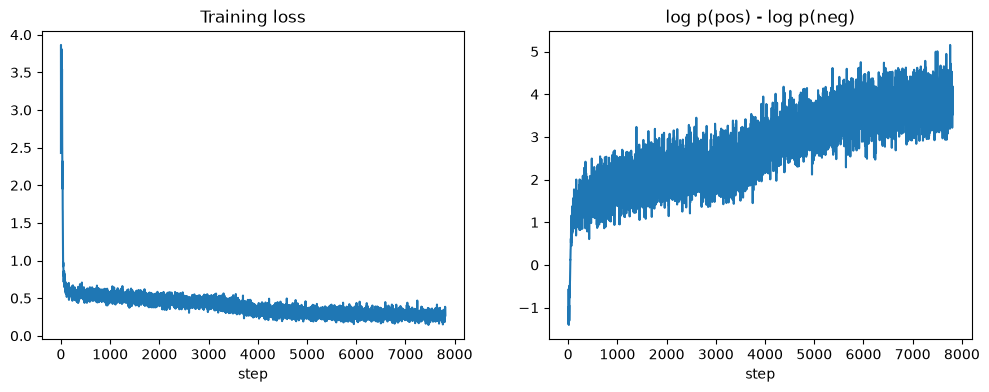

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set_title("Training loss")
axes[0].set_xlabel("step")
axes[1].plot(margin_history)
axes[1].set_title("log p(pos) - log p(neg)")
axes[1].set_xlabel("step")
plt.show()

### Step 8: Begin testing (**students are required to complete this part!**)

In [ ]:
# Load the fine-tuned model
ckpt_path = "../dpo/dpo.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])
gpt = GPT(gptconf).to(device)
try:
    state_dict = checkpoint['model']
except:
    state_dict = checkpoint['model_state_dict']
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
gpt.load_state_dict(state_dict)
# Test
gpt.eval()
test_set = ["17+19=?", "3*17=?", "72/4=?", "72-x=34,x=?", "x*11=44,x=?", "3*17=?", "72/4=?", "72-x=34,x=?"]
with torch.no_grad():
    for prompt in test_set: 
        prompt_ids = encode(prompt)
        x = torch.tensor(prompt_ids, dtype=torch.long, device=device)[None, :]
        # generate() stops by itself at '\n' or '.', and returns (ids, hidden_state)
        y, _ = gpt.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
        print(decode(y[0].tolist()))

### Step 8.1: Accuracy on newly generated problems
The eight prompts above are only a small sample, so we generate 500 new problems with the Task 1 generators, using a different seed, and check the number after "The answer is". Decoding is greedy (`top_k=1`) so the result is deterministic. Some of these problems may also appear in the training set, because the space of small-number problems is limited.

In [ ]:
random.seed(2026)
num_eval = 500
correct = {g.__name__: [0, 0] for g in generators}
with torch.no_grad():
    for _ in range(num_eval):
        gen = random.choice(generators)
        q, ans, _, _ = gen()
        x = torch.tensor(encode(q), dtype=torch.long, device=device)[None, :]
        y, _ = gpt.generate(x, max_new_tokens, temperature=1.0, top_k=1)
        out = decode(y[0].tolist())
        try:
            pred = int(out.split("The answer is ")[1].split(" ")[0])
        except (IndexError, ValueError):
            pred = None
        correct[gen.__name__][0] += int(pred == ans)
        correct[gen.__name__][1] += 1

total = sum(c for c, _ in correct.values())
print(f"Overall accuracy: {total}/{num_eval} = {total / num_eval:.1%}")
for name, (c, n) in correct.items():
    print(f"  {name:14s} {c:3d}/{n:3d} = {c / max(n, 1):.1%}")